# 🧠 What is a Progressive GAN?

Progressive GAN is a type of GAN that learns to generate high-resolution images step by step, starting from very small ones — like how a baby learns to draw by starting with stick figures and gradually adding more details.



---



### 🎨 Real-Life Analogy

Imagine teaching someone to draw a portrait:

	1.	First, they start by sketching a tiny 4×4 face — just blobs.
	2.	Then move to 8×8, add basic eyes and mouth.
	3.	Then 16×16, add eyebrows, ears.
	4.	And keep going — all the way to 1024×1024 for full detail.

Each stage adds more features and realism — just like leveling up in a game.

---

### 🧱 What Makes Progressive GAN Special?
-	Starts simple: It trains on small images first (e.g., 4×4 pixels).
-	Adds layers gradually: As it gets better, it adds more layers to generate bigger, clearer images (like 8×8 → 16×16 → 32×32…).
-	Stable training: It avoids the instability many GANs face when trying to learn everything all at once.

---

### 🖼️ Results
-	It can generate ultra high-quality images, like realistic human faces, even at 1024×1024 resolution — hard to tell from real photos.

### Generate Artificial Faces with CelebA Progressive GAN Model


### Setup

In [1]:
# Install imageio for creating animations.
!pip -q install imageio
!pip -q install scikit-image
!pip install git+https://github.com/tensorflow/docs

  Cloning https://github.com/tensorflow/docs to /tmp/pip-req-build-s0h7vw24
  Running command git clone --filter=blob:none --quiet https://github.com/tensorflow/docs /tmp/pip-req-build-s0h7vw24
  Resolved https://github.com/tensorflow/docs to commit 0054afff57cd4a4ea5389088a89942603461ee6f
  Preparing metadata (setup.py) ... done


In [2]:
#@title Imports and function definitions
from absl import logging

import imageio
import PIL.Image
import matplotlib.pyplot as plt
import numpy as np

import tensorflow as tf
tf.random.set_seed(0)

import tensorflow_hub as hub
from tensorflow_docs.vis import embed
import time

try:
  from google.colab import files
except ImportError:
  pass

from IPython import display
from skimage import transform

# We could retrieve this value from module.get_input_shapes() if we didn't know
# beforehand which module we will be using.
latent_dim = 512


# Interpolates between two vectors that are non-zero and don't both lie on a
# line going through origin. First normalizes v2 to have the same norm as v1.
# Then interpolates between the two vectors on the hypersphere.
def interpolate_hypersphere(v1, v2, num_steps):
  v1_norm = tf.norm(v1)
  v2_norm = tf.norm(v2)
  v2_normalized = v2 * (v1_norm / v2_norm)

  vectors = []
  for step in range(num_steps):
    interpolated = v1 + (v2_normalized - v1) * step / (num_steps - 1)
    interpolated_norm = tf.norm(interpolated)
    interpolated_normalized = interpolated * (v1_norm / interpolated_norm)
    vectors.append(interpolated_normalized)
  return tf.stack(vectors)

# Simple way to display an image.
def display_image(image):
  image = tf.constant(image)
  image = tf.image.convert_image_dtype(image, tf.uint8)
  return PIL.Image.fromarray(image.numpy())

# Given a set of images, show an animation.
def animate(images):
  images = np.array(images)
  converted_images = np.clip(images * 255, 0, 255).astype(np.uint8)
  imageio.mimsave('./animation.gif', converted_images)
  return embed.embed_file('./animation.gif')

logging.set_verbosity(logging.ERROR)

## Latent space interpolation

### Random vectors

Latent space interpolation between two randomly initialized vectors. We will use a TF Hub module [progan-128](https://tfhub.dev/google/progan-128/1) that contains a pre-trained Progressive GAN.

In [3]:
progan = hub.load("https://tfhub.dev/google/progan-128/1").signatures['default']


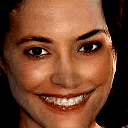

In [4]:
def interpolate_between_vectors():
  v1 = tf.random.normal([latent_dim])
  v2 = tf.random.normal([latent_dim])

  # Creates a tensor with 25 steps of interpolation between v1 and v2.
  vectors = interpolate_hypersphere(v1, v2, 50)

  # Uses module to generate images from the latent space.
  interpolated_images = progan(vectors)['default']

  return interpolated_images

interpolated_images = interpolate_between_vectors()
animate(interpolated_images)

## Finding closest vector in latent space
Fix a target image. As an example use an image generated from the module or upload your own.

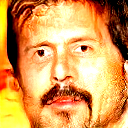

In [5]:
image_from_module_space = True  # @param { isTemplate:true, type:"boolean" }

def get_module_space_image():
  vector = tf.random.normal([1, latent_dim])
  images = progan(vector)['default'][0]
  return images

def upload_image():
  uploaded = files.upload()
  image = imageio.imread(uploaded[list(uploaded.keys())[0]])
  return transform.resize(image, [128, 128])

if image_from_module_space:
  target_image = get_module_space_image()
else:
  target_image = upload_image()

display_image(target_image)

After defining a loss function between the target image and the image generated by a latent space variable, we can use gradient descent to find variable values that minimize the loss.

In [6]:
tf.random.set_seed(42)
initial_vector = tf.random.normal([1, latent_dim])

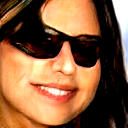

In [7]:
display_image(progan(initial_vector)['default'][0])

In [8]:
def find_closest_latent_vector(initial_vector, num_optimization_steps,
                               steps_per_image):
  images = []
  losses = []

  vector = tf.Variable(initial_vector)
  optimizer = tf.optimizers.Adam(learning_rate=0.01)
  loss_fn = tf.losses.MeanAbsoluteError(reduction="sum")

  for step in range(num_optimization_steps):
    if (step % 100)==0:
      print()
    print('.', end='')
    with tf.GradientTape() as tape:
      image = progan(vector.read_value())['default'][0]
      if (step % steps_per_image) == 0:
        images.append(image.numpy())
      target_image_difference = loss_fn(image, target_image[:,:,:3])
      # The latent vectors were sampled from a normal distribution. We can get
      # more realistic images if we regularize the length of the latent vector to
      # the average length of vector from this distribution.
      regularizer = tf.abs(tf.norm(vector) - np.sqrt(latent_dim))

      loss = target_image_difference + regularizer
      losses.append(loss.numpy())
    grads = tape.gradient(loss, [vector])
    optimizer.apply_gradients(zip(grads, [vector]))

  return images, losses


num_optimization_steps=1000
steps_per_image=10
images, loss = find_closest_latent_vector(initial_vector, num_optimization_steps, steps_per_image)


....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
..........................................................................................

(0.0, 6727.831155395508)

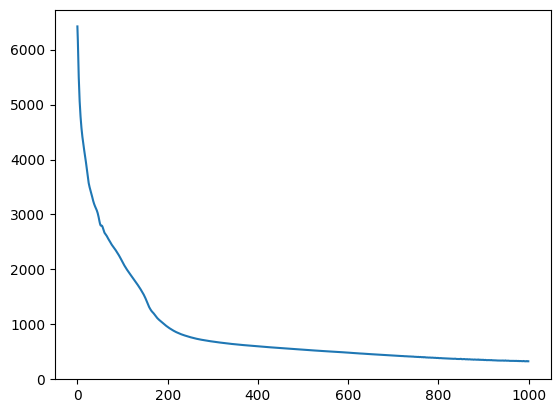

In [9]:
plt.plot(loss)
plt.ylim([0,max(plt.ylim())])


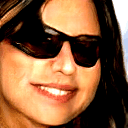

In [10]:
animate(np.stack(images))

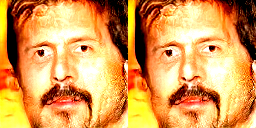

In [11]:
display_image(np.concatenate([images[-1], target_image], axis=1))